# Yahoo Finance Stock Analysis

**Kyria (Zhixuan) Hu**

## Introduction

This project applies data science and machine learning techniques to financial market analysis using historical stock data from Yahoo Finance.

The analysis covers data retrieval and preprocessing, exploratory data analysis, technical indicators, trading strategy design and backtesting, portfolio optimization, and predictive modeling. It also explores financial concepts including the Capital Asset Pricing Model (CAPM) and the Efficient Frontier.

The project begins with Apple Inc. (AAPL) as the primary stock for time-series analysis and later expands to multiple assets for portfolio-level analysis.

## 1. Data Retrieval and Preprocessing


Historical stock price data is retrieved from Yahoo Finance using the `yfinance` Python package. The initial analysis focuses on Apple Inc. (AAPL) from January 2010 through December 2022.

The dataset is inspected for its structure and dimensions before basic preprocessing is performed to remove missing observations and duplicate records.

In [155]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

### Historical Stock Data

In [156]:
ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2022-12-31"

data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

In [157]:
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (3272, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.400961,6.415617,6.352208,6.383613,493729600
2010-01-05,6.412027,6.448218,6.378229,6.418608,601904800
2010-01-06,6.310036,6.437451,6.303456,6.412028,552160000
2010-01-07,6.298370,6.340842,6.252608,6.333365,477131200
2010-01-08,6.340243,6.340842,6.252908,6.289995,447610800


### Data Cleaning

Missing observations and duplicate rows are removed before further analysis.

In [158]:
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

print(f"Cleaned dataset shape: {data.shape}")

Cleaned dataset shape: (3272, 5)


## 2. Exploratory Data Analysis

To examine the historical behavior of AAPL, I visualize its closing price over time and summarize the distribution of the stock data using descriptive statistics.

### Historical Closing Prices

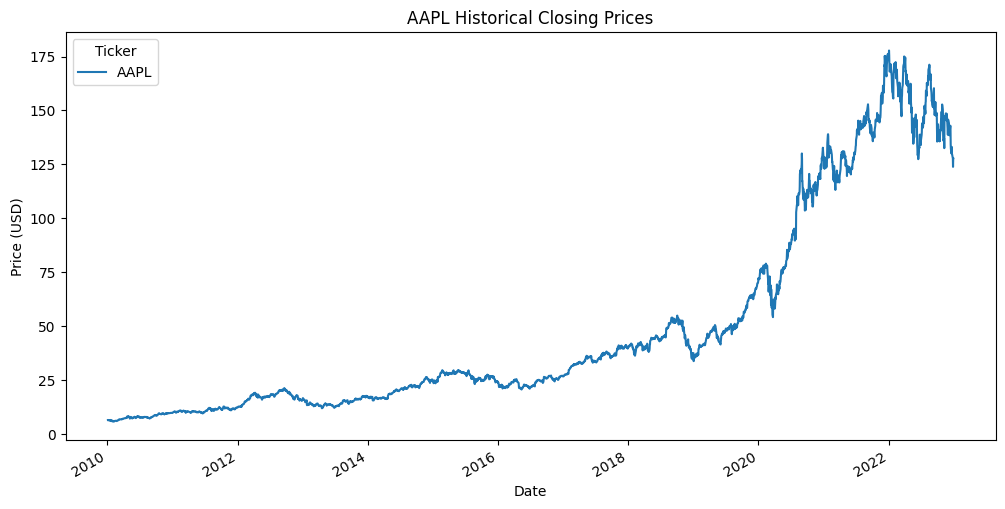

In [159]:
data['Close'].plot(
    title='AAPL Historical Closing Prices',
    figsize=(12, 6)
)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

### Descriptive Statistics

Summary statistics provide an overview of the distribution, variability, and range of the historical stock data.

In [160]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,3272.000000,3272.000000,3272.000000,3272.000000,3.272000e+03
mean,48.602207,49.124012,48.041501,48.579159,2.562707e+08
std,46.985327,47.560737,46.367580,46.957518,2.225648e+08
min,5.744145,5.862288,5.690307,5.753717,3.519590e+07
25%,16.334746,16.520708,16.202983,16.334067,1.023541e+08
50%,26.906128,27.120381,26.774068,26.965469,1.666698e+08
75%,53.989786,54.663956,53.599755,54.142772,3.456643e+08
max,177.786392,178.694819,174.963456,178.392015,1.880998e+09


## 3. Moving Average Analysis

To examine short- and medium-term price trends, I calculate 10-day and 50-day simple moving averages (SMAs) for AAPL. Comparing these moving averages with the closing price helps identify changes in price momentum and provides the basis for the crossover strategy evaluated in the next section.

### Simple Moving Averages

In [161]:
data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

data[['Close', 'MA10', 'MA50']].tail()

Price,Close,MA10,MA50
Ticker,AAPL,,
Date,,,
2022-12-23,129.547684,134.439362,141.532724
2022-12-27,127.749748,133.018716,141.373156
2022-12-28,123.829742,131.109791,141.056131
2022-12-29,127.337105,129.773634,140.782968
2022-12-30,127.651512,129.128156,140.513935


### Price and Moving Average Trends

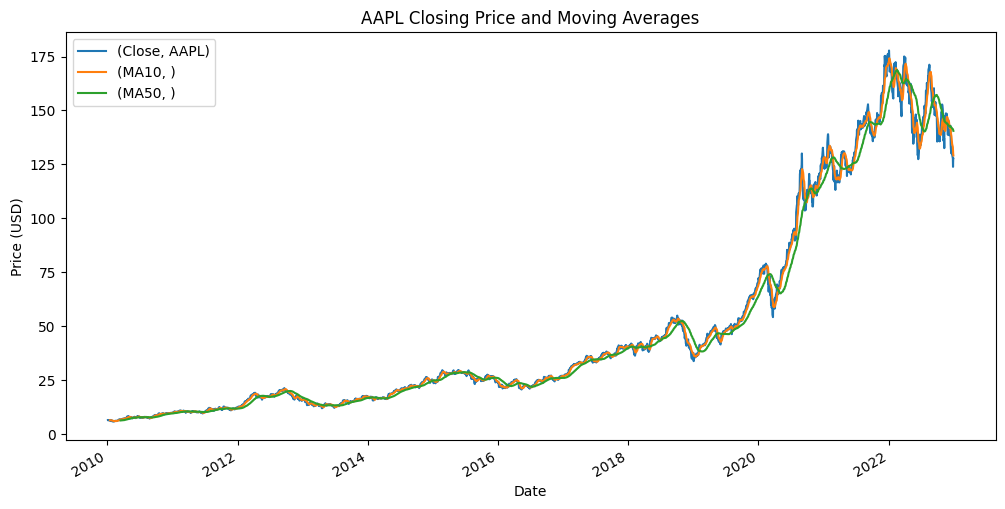

In [162]:
data[['Close', 'MA10', 'MA50']].plot(
    title='AAPL Closing Price and Moving Averages',
    figsize=(12, 6)
)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 4. Moving Average Crossover Strategy

Building on the moving average analysis, I construct a simple crossover strategy using the 10-day and 50-day SMAs. The strategy takes a long position when the short-term moving average rises above the long-term moving average and exits the position when the relationship reverses.

### Trading Signals

In [163]:
data['Signal'] = np.where(data['MA10'] > data['MA50'], 1, 0)
data['Position'] = data['Signal'].diff()

data['Position'].value_counts()

,count
Position,
0.0,3193
1.0,39
-1.0,39


### Buy and Sell Signals

Crossover points are visualized alongside the historical closing price. A positive change in the signal represents an entry point, while a negative change represents an exit point.

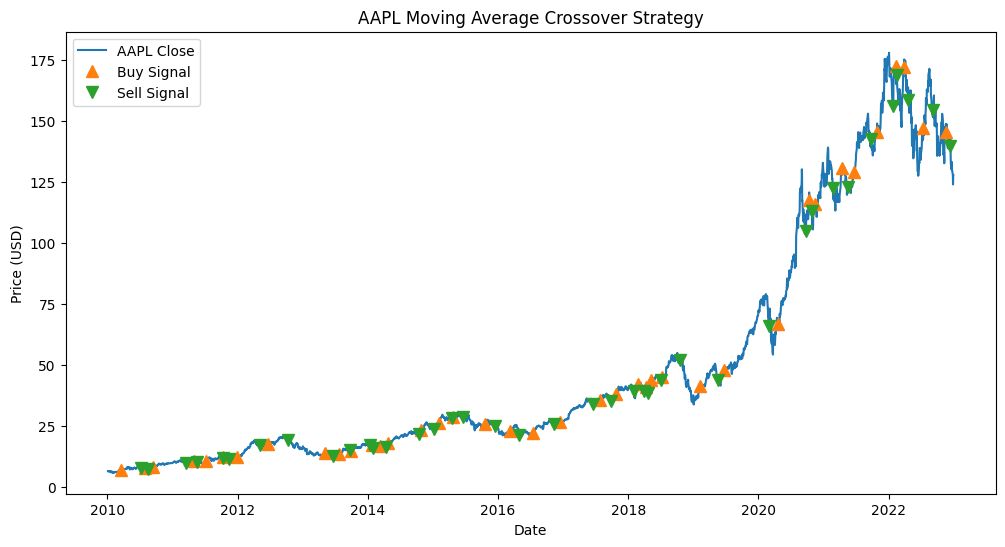

In [164]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data['Close'], label='AAPL Close')

plt.plot(
    data[data['Position'] == 1].index,
    data.loc[data['Position'] == 1, 'Close'],
    '^',
    markersize=8,
    label='Buy Signal'
)

plt.plot(
    data[data['Position'] == -1].index,
    data.loc[data['Position'] == -1, 'Close'],
    'v',
    markersize=8,
    label='Sell Signal'
)

plt.title('AAPL Moving Average Crossover Strategy')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 5. Strategy Backtesting

To evaluate the crossover strategy, I simulate its historical performance using daily AAPL returns. The trading signal is shifted by one day so that each position is based only on information available before the corresponding return is realized.

The strategy starts with an initial portfolio value of $100,000 and remains either invested in AAPL or out of the market depending on the moving average signal.

In [165]:
initial_capital = 100000

backtest = pd.DataFrame(index=data.index)

backtest['Market_Return'] = data['Close'].pct_change()

# Use the previous day's signal to avoid look-ahead bias
backtest['Strategy_Return'] = (
    data['Signal'].shift(1) * backtest['Market_Return']
)

backtest['Portfolio_Value'] = (
    initial_capital *
    (1 + backtest['Strategy_Return'].fillna(0)).cumprod()
)

backtest.tail()

,Market_Return,Strategy_Return,Portfolio_Value
Date,,,
2022-12-23,-0.002798,-0.0,925020.412823
2022-12-27,-0.013879,-0.0,925020.412823
2022-12-28,-0.030685,-0.0,925020.412823
2022-12-29,0.028324,0.0,925020.412823
2022-12-30,0.002469,0.0,925020.412823


### Portfolio Performance

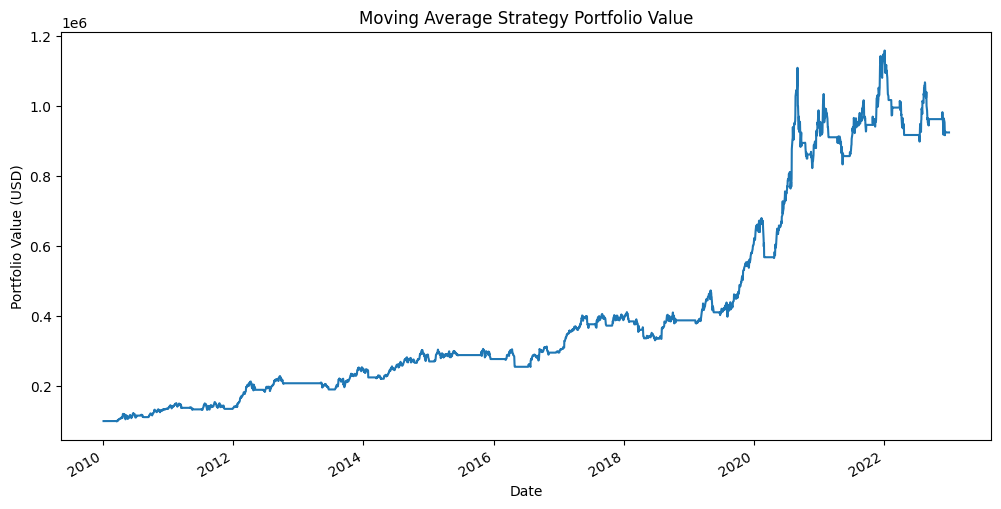

In [166]:
backtest['Portfolio_Value'].plot(
    title='Moving Average Strategy Portfolio Value',
    figsize=(12, 6)
)

plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.show()

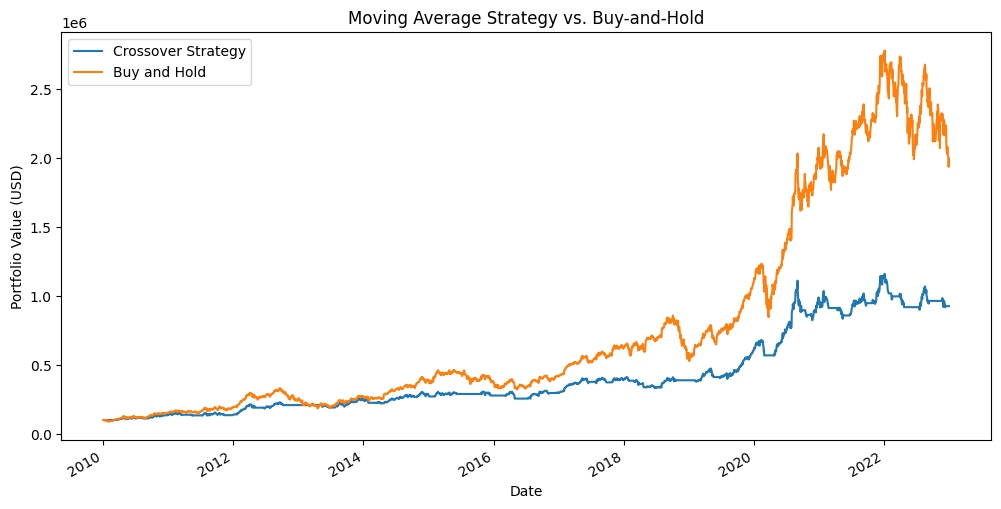

In [167]:
backtest['Buy_Hold_Value'] = (
    initial_capital *
    (1 + backtest['Market_Return'].fillna(0)).cumprod()
)

backtest[['Portfolio_Value', 'Buy_Hold_Value']].plot(
    title='Moving Average Strategy vs. Buy-and-Hold',
    figsize=(12, 6)
)

plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(['Crossover Strategy', 'Buy and Hold'])
plt.show()

The crossover strategy produced positive cumulative returns over the sample period but substantially underperformed a passive buy-and-hold strategy. This illustrates an important limitation of trend-following rules in strongly appreciating markets: downside protection may come at the cost of missing portions of sustained upward trends.

## 6. Machine Learning for Next-Day Direction Prediction

I next explore whether recent price behavior can be used to predict the direction of AAPL's next-day return.

The target is defined as 1 when the following trading day's return is positive and 0 otherwise. Three classification models are compared: Logistic Regression, Random Forest, and Support Vector Machine (SVM).

### Feature Engineering

In [168]:
ml_data = data[['Close']].copy()

ml_data['Returns'] = ml_data['Close'].pct_change()
ml_data['MA10'] = ml_data['Close'].rolling(window=10).mean()
ml_data['MA50'] = ml_data['Close'].rolling(window=50).mean()

# Define next-day return and remove rows without complete information
ml_data['Future_Return'] = ml_data['Returns'].shift(-1)
ml_data.dropna(inplace=True)

# Binary target: 1 if the next-day return is positive, 0 otherwise
ml_data['Target'] = (ml_data['Future_Return'] > 0).astype(int)

ml_data.head()

Price,Close,Returns,MA10,MA50,Future_Return,Target
Ticker,AAPL,,,,,
Date,,,,,,
2010-03-16,6.713213,0.002725,6.599022,6.190020,-0.001470,0
2010-03-17,6.703346,-0.001470,6.643258,6.196067,0.002365,1
2010-03-18,6.719199,0.002365,6.684952,6.202211,-0.010683,0
2010-03-19,6.647417,-0.010683,6.694822,6.208958,0.011249,1
2010-03-22,6.722191,0.011249,6.711781,6.217435,0.016062,1


### Chronological Train-Test Split

Because financial observations are time-dependent, the dataset is split chronologically rather than randomly. The first 80% of observations are used for training and the remaining 20% are reserved for out-of-sample testing.

In [169]:
X = ml_data[['Returns', 'MA10', 'MA50']]
y = ml_data['Target']

split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [170]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression()
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42
    ),
    'SVM': make_pipeline(
        StandardScaler(),
        SVC()
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f'{name}: {accuracy:.3f}')

Logistic Regression: 0.491
Random Forest: 0.488
SVM: 0.509


## 7. Model Evaluation

Accuracy alone provides limited information about classification performance, particularly when evaluating predictions across both positive and negative return classes. I therefore examine each model using a confusion matrix and classification report, including precision, recall, and F1-score.

### Classification Performance

In [171]:
from sklearn.metrics import confusion_matrix, classification_report

for name, model in models.items():
    predictions = model.predict(X_test)

    print(f"\n{name}")
    print("-" * 50)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        predictions,
        digits=3,
        zero_division=0
        )
    )




Logistic Regression
--------------------------------------------------
Confusion Matrix:
[[ 87 228]
 [100 230]]

Classification Report:
              precision    recall  f1-score   support

           0      0.465     0.276     0.347       315
           1      0.502     0.697     0.584       330

    accuracy                          0.491       645
   macro avg      0.484     0.487     0.465       645
weighted avg      0.484     0.491     0.468       645


Random Forest
--------------------------------------------------
Confusion Matrix:
[[315   0]
 [330   0]]

Classification Report:
              precision    recall  f1-score   support

           0      0.488     1.000     0.656       315
           1      0.000     0.000     0.000       330

    accuracy                          0.488       645
   macro avg      0.244     0.500     0.328       645
weighted avg      0.239     0.488     0.320       645


SVM
--------------------------------------------------
Confusion Matrix:
[[  

## 8. Model Performance Visualization

To complement the numerical evaluation, I visualize the confusion matrix for each classifier. These plots make it easier to compare how the models classify positive and negative return days and highlight the class-specific prediction patterns identified in the previous section.

### Confusion Matrices

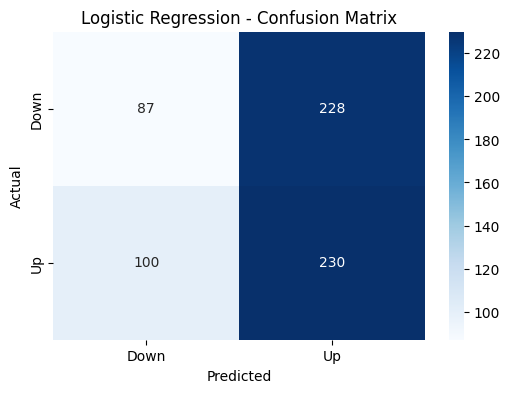

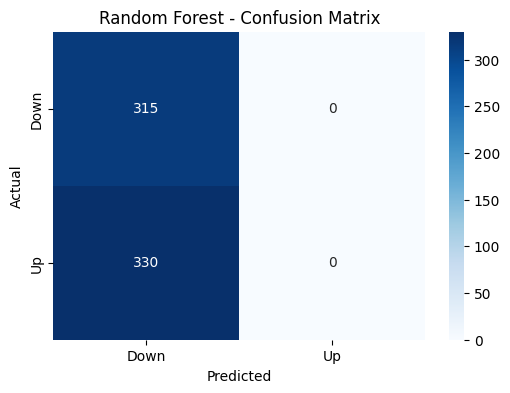

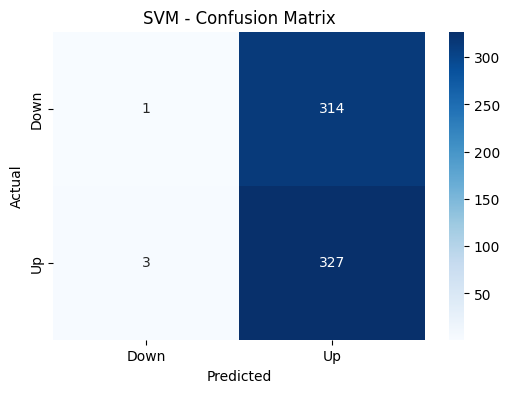

In [172]:
for name, model in models.items():
    predictions = model.predict(X_test)
    conf_matrix = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 4))

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Down', 'Up'],
        yticklabels=['Down', 'Up']
    )

    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 9. CAPM Parameter Estimation

The Capital Asset Pricing Model (CAPM) relates an asset's excess return to the market's excess return. In this section, I estimate alpha and beta for Tesla (TSLA), Microsoft (MSFT), and Goldman Sachs (GS) using the S&P 500 as the market benchmark.

The CAPM regression is specified as:

$$
R_i - R_f = \alpha_i + \beta_i (R_m - R_f) + \varepsilon_i
$$

where:

- $R_i$ is the return of asset $i$
- $R_f$ is the risk-free rate
- $R_m$ is the market return
- $\alpha_i$ captures average return not explained by market movements
- $\beta_i$ measures the asset's sensitivity to market excess returns
- $\varepsilon_i$ is the residual component

### Data Preparation

Daily closing prices are collected for TSLA, MSFT, GS, and the S&P 500. Returns are then converted to excess returns using an assumed annual risk-free rate of 4%.

In [173]:
import statsmodels.api as sm

In [174]:
tickers = ['TSLA', 'MSFT', 'GS', '^GSPC']

capm_prices = yf.download(
    tickers,
    start='2022-01-01',
    end='2022-12-31',
    auto_adjust=True,
    progress=False
)['Close']

capm_prices = capm_prices.rename(columns={'^GSPC': 'SP500'})

In [175]:
capm_returns = capm_prices.pct_change().dropna()

rf_annual = 0.04
rf_daily = (1 + rf_annual) ** (1 / 252) - 1

capm_returns['RF'] = rf_daily

In [176]:
excess_returns = pd.DataFrame({
    'SP500_exc': capm_returns['SP500'] - capm_returns['RF']
})

for stock in ['TSLA', 'MSFT', 'GS']:
    excess_returns[f'{stock}_exc'] = (
        capm_returns[stock] - capm_returns['RF']
    )

excess_returns.head()

,SP500_exc,TSLA_exc,MSFT_exc,GS_exc
Date,,,,
2022-01-04,-0.000785,-0.041988,-0.017303,0.030578
2022-01-05,-0.019548,-0.053627,-0.038543,-0.021875
2022-01-06,-0.001119,-0.021679,-0.008058,-0.004420
2022-01-07,-0.004206,-0.035602,0.000354,0.001306
2022-01-10,-0.001597,0.030186,0.000577,0.004020


In [177]:
def run_capm(y_excess, market_excess):
    X = sm.add_constant(market_excess)
    return sm.OLS(y_excess, X).fit()

In [178]:
capm_results = {}

for stock in ['TSLA', 'MSFT', 'GS']:
    model = run_capm(
        excess_returns[f'{stock}_exc'],
        excess_returns['SP500_exc']
    )

    capm_results[stock] = {
        'Alpha': model.params['const'],
        'Beta': model.params['SP500_exc'],
        'R_squared': model.rsquared
    }

capm_summary = pd.DataFrame(capm_results).T
capm_summary.index.name = 'Ticker'

capm_summary.round(4)

,Alpha,Beta,R_squared
Ticker,,,
TSLA,-0.0024,1.7365,0.4141
MSFT,-0.0000,1.2845,0.7725
GS,0.0004,0.9579,0.6199


### Interpretation

TSLA has the highest estimated beta at 1.74, indicating substantially greater sensitivity to market movements than the other two stocks. MSFT also has a beta above 1 at 1.28, while GS has a beta close to 1, suggesting market sensitivity similar to the S&P 500.

The model explains the largest share of return variation for MSFT ($R^2 = 0.77$), followed by GS ($R^2 = 0.62$). TSLA has a lower $R^2$ of 0.41, suggesting that a larger portion of its return variation is driven by factors not captured by the market factor alone.

Estimated daily alpha is close to zero for MSFT and GS, while TSLA has a negative estimated alpha over the 2022 sample period. These estimates should be interpreted in the context of the selected time period and the simplifying assumption of a constant 4% annual risk-free rate.

## 10. Efficient Frontier and Portfolio Optimization

Modern Portfolio Theory examines the trade-off between expected return and portfolio risk. In this section, I construct an efficient frontier using five stocks, NVDA, GOOGL, GS, LLY, and WMT, and identify the minimum-volatility portfolio under long-only constraints.

The S&P 500 is included as a market benchmark for estimating each stock's market sensitivity before the portfolio optimization step.

### Data Preparation

Daily closing prices are collected from June 2023 through June 2025 for five stocks and the S&P 500 index.

In [179]:
portfolio_tickers = ["NVDA", "GOOGL", "GS", "LLY", "WMT", "^GSPC"]
start_date = "2023-06-05"
end_date = "2025-06-05"

portfolio_prices = yf.download(
    portfolio_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)['Close']

portfolio_prices.head()

Ticker,GOOGL,GS,LLY,NVDA,WMT,^GSPC
Date,,,,,,
2023-06-05,124.822243,298.511810,434.270020,39.090790,48.213730,4273.790039
2023-06-06,126.109978,303.140503,433.106812,38.574848,48.207283,4283.850098
2023-06-07,121.345314,311.442566,426.557404,37.402134,48.278091,4267.520020
2023-06-08,120.988708,311.182861,435.638489,38.435123,48.976513,4293.930176
2023-06-09,121.077873,311.693054,436.010040,38.694622,49.272617,4298.859863


### Return and Risk Statistics

Daily returns are used to estimate average returns, covariance, correlation, and annualized volatility for the selected assets.

In [180]:
portfolio_returns = portfolio_prices.pct_change().dropna()

mean_daily_returns = portfolio_returns.mean()
cov_matrix_daily = portfolio_returns.cov()
corr_matrix_daily = portfolio_returns.corr()

trading_days = 252

mean_annual_returns = mean_daily_returns * trading_days
cov_matrix_annual = cov_matrix_daily * trading_days
volatility_annual = portfolio_returns.std() * np.sqrt(trading_days)

In [181]:
risk_return_summary = pd.DataFrame({
    'Annualized Return': mean_annual_returns,
    'Annualized Volatility': volatility_annual
})

risk_return_summary.round(4)

,Annualized Return,Annualized Volatility
Ticker,,
GOOGL,0.1919,0.2988
GS,0.3787,0.2861
LLY,0.3404,0.3459
NVDA,0.7833,0.5203
WMT,0.3800,0.2075
^GSPC,0.1811,0.1611


### Market Beta Estimation

Before constructing the portfolio, I estimate each stock's sensitivity to movements in the S&P 500 using a simple market regression. Unlike the CAPM specification in the previous section, this regression uses raw stock and market returns rather than excess returns.

In [182]:
market_returns = portfolio_returns["^GSPC"]
stock_returns = portfolio_returns.drop(columns="^GSPC")

market_regression_results = {}

for ticker in stock_returns.columns:
    X = sm.add_constant(market_returns)
    model = sm.OLS(stock_returns[ticker], X).fit()

    market_regression_results[ticker] = {
        'Alpha_daily': model.params['const'],
        'Beta': model.params['^GSPC'],
        'R_squared': model.rsquared
    }

market_regression_table = pd.DataFrame(market_regression_results).T

market_regression_table.round(4)

,Alpha_daily,Beta,R_squared
GOOGL,-0.0000,1.1280,0.3698
GS,0.0006,1.2793,0.5185
LLY,0.0008,0.7489,0.1216
NVDA,0.0015,2.1982,0.4630
WMT,0.0011,0.5527,0.1840


### Efficient Frontier

Using annualized historical returns and the covariance matrix, I solve for long-only portfolio weights that minimize volatility at different target-return levels.

Each portfolio is constrained so that the asset weights sum to 1 and individual weights remain between 0 and 1.

In [183]:
from scipy.optimize import minimize

def efficient_frontier(mu, covariance_matrix, n_points=60):
    n_assets = len(mu)

    frontier_volatility = []
    frontier_returns = []
    frontier_weights = []

    target_returns = np.linspace(mu.min(), mu.max(), n_points)

    for target_return in target_returns:

        def portfolio_volatility(weights):
            return np.sqrt(
                weights @ covariance_matrix @ weights
            )

        constraints = (
            {
                'type': 'eq',
                'fun': lambda weights: np.sum(weights) - 1
            },
            {
                'type': 'eq',
                'fun': lambda weights: weights @ mu - target_return
            }
        )

        bounds = [(0, 1)] * n_assets
        initial_weights = np.repeat(1 / n_assets, n_assets)

        result = minimize(
            portfolio_volatility,
            initial_weights,
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            frontier_volatility.append(result.fun)
            frontier_returns.append(target_return)
            frontier_weights.append(result.x)

    return (
        np.array(frontier_volatility),
        np.array(frontier_returns),
        frontier_weights
    )

In [184]:
asset_tickers = ["NVDA", "GOOGL", "GS", "LLY", "WMT"]

mu_vector = mean_annual_returns.loc[asset_tickers].values

covariance_submatrix = cov_matrix_annual.loc[
    asset_tickers,
    asset_tickers
].values

frontier_volatility, frontier_returns, frontier_weights = (
    efficient_frontier(
        mu_vector,
        covariance_submatrix,
        n_points=60
    )
)

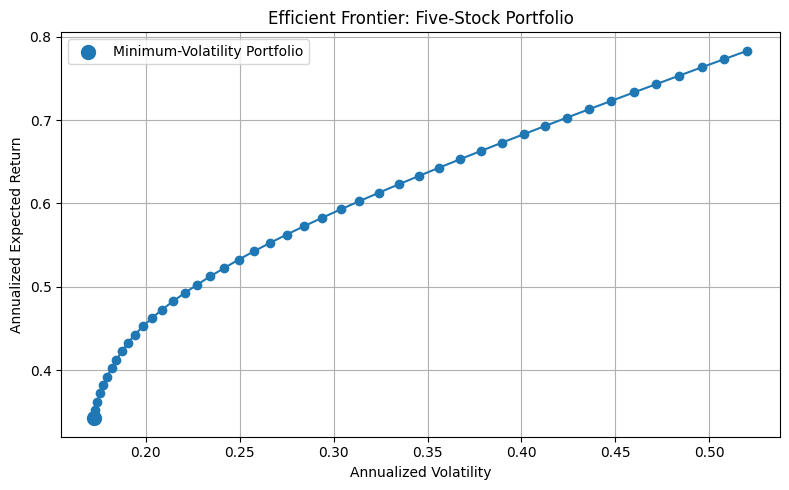

In [185]:
min_vol_index = np.argmin(frontier_volatility)

plt.figure(figsize=(8, 5))

plt.plot(
    frontier_volatility[min_vol_index:],
    frontier_returns[min_vol_index:],
    marker='o',
    linestyle='-'
)

plt.scatter(
    frontier_volatility[min_vol_index],
    frontier_returns[min_vol_index],
    s=100,
    label='Minimum-Volatility Portfolio'
)

plt.title('Efficient Frontier: Five-Stock Portfolio')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Expected Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Minimum-Volatility Portfolio

The portfolio with the lowest estimated volatility along the frontier is identified together with its expected return and asset allocation.

In [186]:
min_vol_index = np.argmin(frontier_volatility)

min_volatility = frontier_volatility[min_vol_index]
min_return = frontier_returns[min_vol_index]
min_weights = frontier_weights[min_vol_index]

print(f"Annualized volatility: {min_volatility:.2%}")
print(f"Expected annual return: {min_return:.2%}\n")

for ticker, weight in zip(asset_tickers, min_weights):
    print(f"{ticker}: {weight:.2%}")

Annualized volatility: 17.23%
Expected annual return: 34.22%

NVDA: 0.07%
GOOGL: 17.46%
GS: 16.32%
LLY: 12.64%
WMT: 53.51%


### Interpretation

The minimum-volatility portfolio has an estimated annualized volatility of 17.23% and an expected annual return of 34.22% based on historical sample estimates. WMT receives the largest portfolio weight at 53.51%, followed by GOOGL, GS, and LLY, while NVDA receives a negligible weight despite having the highest historical return.

This allocation reflects the risk-return trade-off underlying portfolio optimization. NVDA generated substantially higher returns during the sample period but also exhibited the highest volatility and market beta, making it less attractive for a minimum-volatility portfolio. In contrast, WMT combined relatively low volatility with strong historical returns over the selected period.

These results are based on historical sample estimates and a long-only, fully invested portfolio, and therefore should not be interpreted as forecasts of future portfolio performance.

## 11. Long-Only Mean Reversion Strategy

As a final trading application, I evaluate a simple mean reversion strategy for NVIDIA (NVDA) using the Relative Strength Index (RSI).

The strategy enters a long position when the 14-day RSI falls below 30, indicating an oversold condition, and remains invested until the RSI rises above 70. Otherwise, the portfolio remains out of the market.

The backtest begins with $10,000 in capital and assumes fractional-share trading.

### Data Preparation

Daily NVDA closing prices are collected from May 2024 through May 2025.

In [187]:
initial_capital = 10_000
ticker = "NVDA"

start_date = "2024-05-29"
end_date = "2025-05-29"

nvda_data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

nvda_prices = nvda_data["Close"].squeeze().dropna()

nvda_prices.head()

,NVDA
Date,
2024-05-29,114.626640
2024-05-30,110.309120
2024-05-31,109.443611
2024-06-03,114.801346
2024-06-04,116.235855


### RSI Calculation

The 14-day Relative Strength Index is calculated from rolling average gains and losses. RSI values below 30 are treated as oversold signals, while values above 70 are treated as exit signals.

In [188]:
rsi_window = 14

price_change = nvda_prices.diff()

gains = price_change.clip(lower=0)
losses = -price_change.clip(upper=0)

average_gain = gains.rolling(window=rsi_window).mean()
average_loss = losses.rolling(window=rsi_window).mean()

relative_strength = average_gain / average_loss

rsi = 100 - (
    100 / (1 + relative_strength)
)

rsi.dropna().head()

,NVDA
Date,
2024-06-18,77.472530
2024-06-20,76.510079
2024-06-21,70.363046
2024-06-24,53.489055
2024-06-25,59.427570


### Trading Positions

The strategy enters a long position when RSI falls below 30 and exits when RSI rises above 70. Between these thresholds, the previous position is maintained.

Positions are shifted by one trading day so that each return is based only on information available before that return is realized.

In [189]:
positions = pd.Series(0.0, index=nvda_prices.index)

current_position = 0

for date in nvda_prices.index:
    if pd.isna(rsi.loc[date]):
        positions.loc[date] = 0
        continue

    if rsi.loc[date] < 30:
        current_position = 1
    elif rsi.loc[date] > 70:
        current_position = 0

    positions.loc[date] = current_position

# Execute each signal on the following trading day
positions = positions.shift(1).fillna(0)

positions.value_counts()

,count
0.0,176
1.0,74


### Strategy Backtest

Daily strategy returns are calculated by applying the long-or-flat position to NVDA's daily returns. Portfolio value is then compounded from the initial $10,000 investment.

In [190]:
nvda_returns = nvda_prices.pct_change().fillna(0)

strategy_returns = positions * nvda_returns

equity_curve = (
    initial_capital *
    (1 + strategy_returns).cumprod()
)

equity_curve.tail()

,0
Date,
2025-05-21,15360.346585
2025-05-22,15360.346585
2025-05-23,15360.346585
2025-05-27,15360.346585
2025-05-28,15360.346585


### Strategy Performance

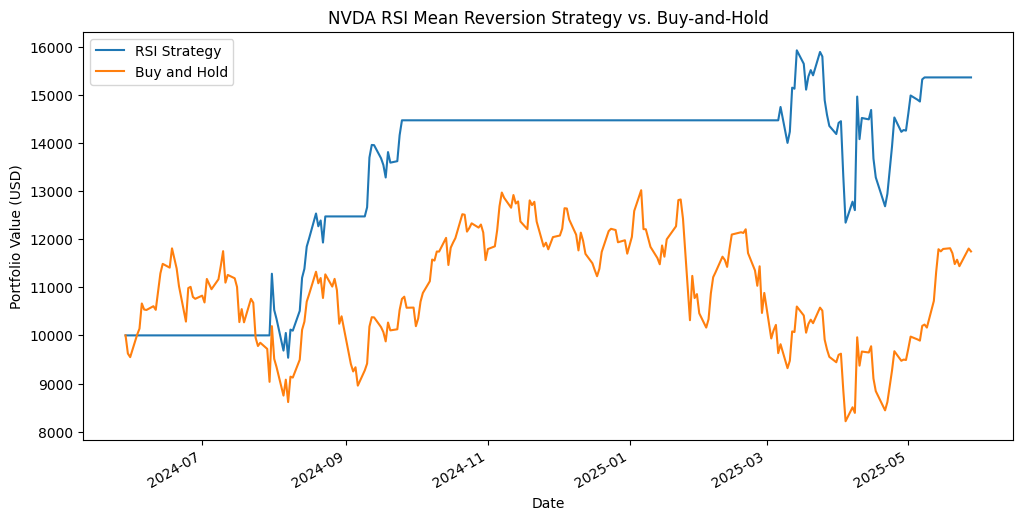

In [191]:
buy_hold_curve = (
    initial_capital *
    (1 + nvda_returns).cumprod()
)

performance = pd.DataFrame({
    'RSI Strategy': equity_curve,
    'Buy and Hold': buy_hold_curve
})

performance.plot(
    title='NVDA RSI Mean Reversion Strategy vs. Buy-and-Hold',
    figsize=(12, 6)
)

plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.show()

In [192]:
final_amount = equity_curve.iloc[-1]
net_profit = final_amount - initial_capital
total_return = final_amount / initial_capital - 1

buy_hold_final = buy_hold_curve.iloc[-1]
buy_hold_return = buy_hold_final / initial_capital - 1

print(f"Initial Capital        : ${initial_capital:,.2f}")
print(f"Final Strategy Value   : ${final_amount:,.2f}")
print(f"Strategy Net Profit    : ${net_profit:,.2f}")
print(f"Strategy Total Return  : {total_return:.2%}")
print(f"Buy-and-Hold Return    : {buy_hold_return:.2%}")

Initial Capital        : $10,000.00
Final Strategy Value   : $15,360.35
Strategy Net Profit    : $5,360.35
Strategy Total Return  : 53.60%
Buy-and-Hold Return    : 17.44%


### Interpretation

Over the selected May 2024 to May 2025 sample period, the RSI-based mean reversion strategy increased the initial portfolio value from USD 10,000 to approximately USD 15,360, corresponding to a total return of 53.60%. Over the same period, a passive buy-and-hold investment in NVDA returned 17.44%.

The strategy remained out of the market for much of the sample and entered long positions only following oversold RSI signals. This helped avoid portions of several NVDA drawdowns while still participating in subsequent price recoveries.

Although the strategy substantially outperformed buy-and-hold in this historical sample, the result should not be interpreted as evidence that the rule will consistently outperform in other periods or assets. The backtest is based on a single stock and time period and does not account for transaction costs, bid-ask spreads, slippage, taxes, or other implementation constraints.